In [16]:
!pip install lightgbm
!pip install catboost
!pip install xgboost
!pip install specificity
!pip install imbalanced-learn

!pip install ipython-autotime
%load_ext autotime

The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime
time: 32.7 s (started: 2026-04-19 03:35:46 +00:00)


In [21]:
import numpy as np
import pandas as pd
import time
from scipy.stats import uniform


from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV, cross_validate
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, BaggingClassifier, StackingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_validate

from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, matthews_corrcoef, cohen_kappa_score, confusion_matrix, balanced_accuracy_score

time: 1.27 ms (started: 2026-04-19 03:43:53 +00:00)


In [22]:
df = pd.read_csv("bank-additional-full.csv", sep = ";")
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


time: 138 ms (started: 2026-04-19 03:43:55 +00:00)


In [23]:
# Reload the DataFrame to ensure 'duration' is present if the cell is run multiple times
df = pd.read_csv("bank-additional-full.csv", sep = ";")

# 3. Drop Leakage Feature
df.drop('duration', axis=1, inplace=True)

# 4. Handle "unknown" Values
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].replace('unknown', df[col].mode()[0])


# 5. Encode Target
df['y'] = df['y'].map({'no': 0, 'yes': 1})

# Drop rows where 'y' is NaN after encoding
df.dropna(subset=['y'], inplace=True)

# 6. One-Hot Encoding
df = pd.get_dummies(df, drop_first=True)
X_shuffled = df.drop('y', axis=1)
y_shuffled = df['y']

# 7. Prepare your data
X_raw = df.drop('y', axis=1)
y_raw = df['y']

# 9. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42
)

# 8. Apply SMOTE
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

# 8. SCALE DATA
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train_sm)
# X_test_scaled = scaler.transform(X_test)


time: 664 ms (started: 2026-04-19 03:43:58 +00:00)


In [24]:
def hyper_parameter_tune(model, param_dist, X_train, y_train):

    search = RandomizedSearchCV(
          model,
          param_distributions=param_dist,
          n_iter=5,
          cv=5,
          refit='roc_auc',
          n_jobs=-1,
          random_state=42,
          return_train_score=False
          )

    search.fit(X_train, y_train)

    best_model = search.best_estimator_

    print("Best parameters:", search.best_params_)
    print("Best CV accuracy: {:.4f}".format(search.best_score_))
    print("Test accuracy: {:.4f}".format(best_model.score(X_test, y_test)))

    return best_model

time: 1.13 ms (started: 2026-04-19 03:44:02 +00:00)


In [25]:
def evaluate_models(name, model, X_shuffled, y_shuffled):

    result = []

    print(f"\nTrain Model: {name}\n")

    kf = KFold(n_splits=10, shuffle=True, random_state=42)

    for fold, (train_idx, test_idx) in enumerate(kf.split(X_shuffled)):
      X_train, X_test = X_shuffled.iloc[train_idx], X_shuffled.iloc[test_idx]
      y_train, y_test = y_shuffled.iloc[train_idx], y_shuffled.iloc[test_idx]

      # Train
      start_time = time.time()
      model.fit(X_train, y_train)
      training_time = time.time() - start_time

      # Predict
      y_pred = model.predict(X_test)

      # Metrics
      acc = accuracy_score(y_test, y_pred)
      prec = precision_score(y_test, y_pred, zero_division=0)
      rec = recall_score(y_test, y_pred, zero_division=0)
      f1 = f1_score(y_test, y_pred, zero_division=0)
      cm = confusion_matrix(y_test, y_pred)
      tn, fp, fn, tp = cm.ravel()
      specificity = tn / (tn + fp) if (tn + fp) != 0 else 0
      fpr = fp / (fp + tn) if (fp + tn) != 0 else 0
      gm = np.sqrt(rec * specificity)
      auc = roc_auc_score(y_test, y_pred)
      mcc = matthews_corrcoef(y_test, y_pred)
      kappa = cohen_kappa_score(y_test, y_pred)
      balanced_acc = balanced_accuracy_score(y_test, y_pred)

      # Store fold results
      result.append({
          "Fold": fold+1,
          "Classifier": name,
          "Accuracy": acc,
          "Precision": prec,
          "Recall": rec,
          "Specificity": specificity,
          "F1": f1,
          "GM": gm,
          "FPR": fpr,
          "AUC": auc,
          "MCC": mcc,
          "Kappa": kappa,
          "Balanced Accuracy": balanced_acc,
          "Training Time (s)": training_time
      })
    return pd.DataFrame(result)

time: 2.22 ms (started: 2026-04-19 03:44:05 +00:00)


In [32]:
from sklearn.ensemble import GradientBoostingClassifier

name = "Gradient Boosting (GBM)" # change as per model

# Model
model = GradientBoostingClassifier() # change as per model

# Parameters, change as per model
param_dist = {
        'n_estimators': [21, 51, 81],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [1, 2, 3, 5],
        'subsample': [0.6, 0.8, 0.9]
    }

best_model = hyper_parameter_tune(model, param_dist, X_train_sm, y_train_sm)


Best parameters: {'subsample': 0.9, 'n_estimators': 81, 'max_depth': 3, 'learning_rate': 0.05}
Best CV accuracy: 0.8301
Test accuracy: 0.8574
time: 59.2 s (started: 2026-04-19 03:51:54 +00:00)



--- SHAP EXPLANATION ---


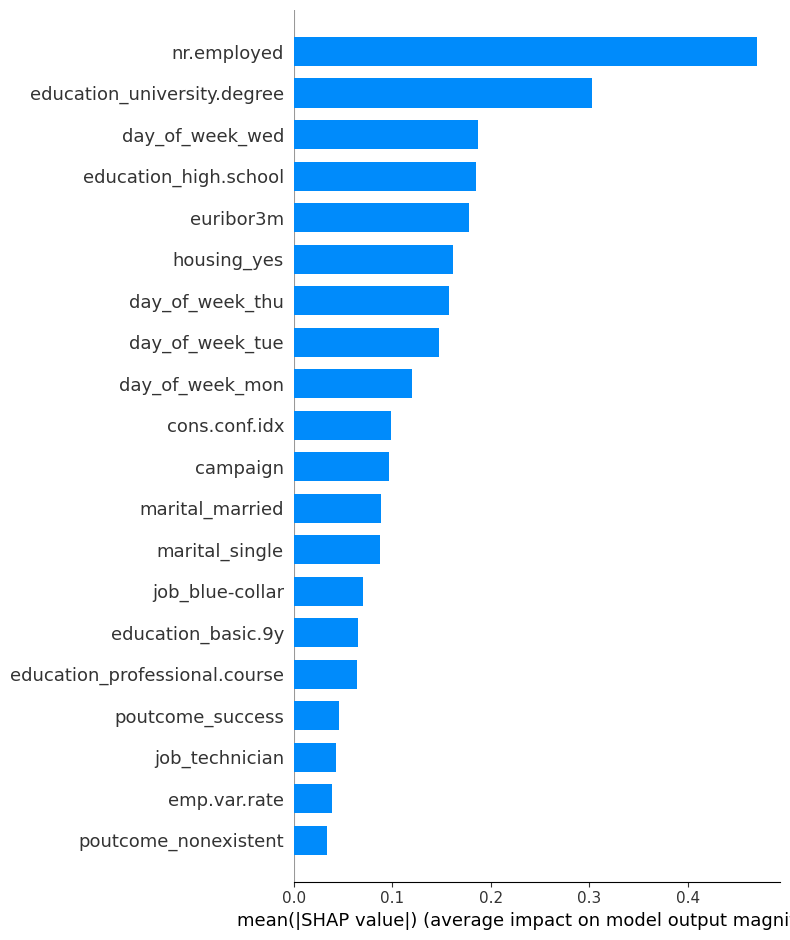

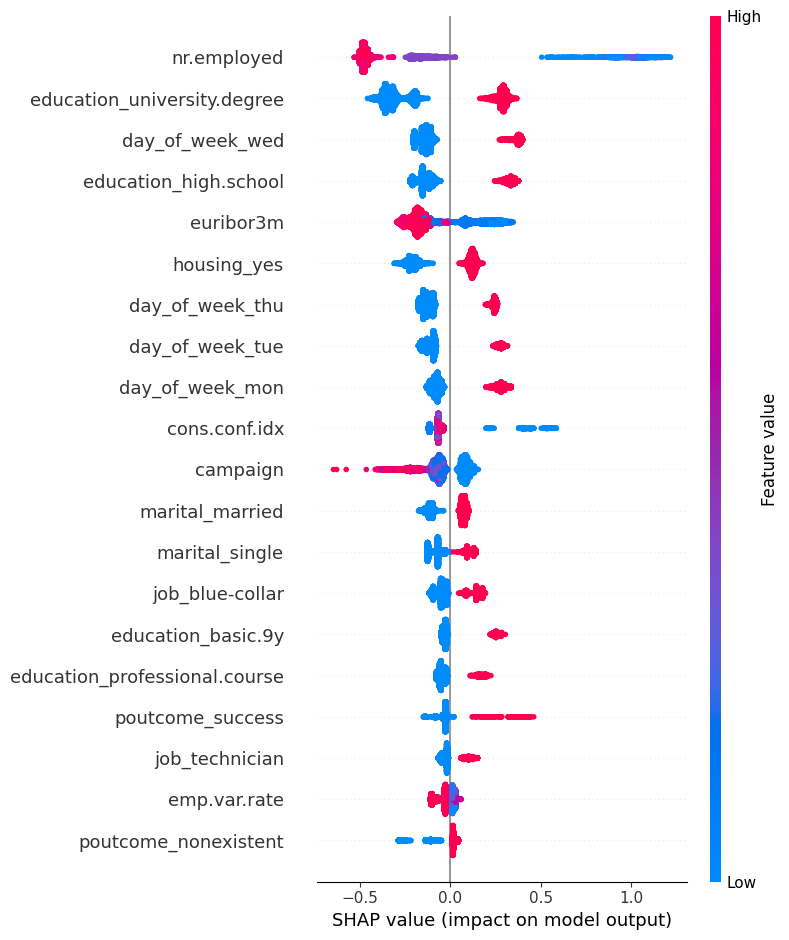

<Figure size 640x480 with 0 Axes>

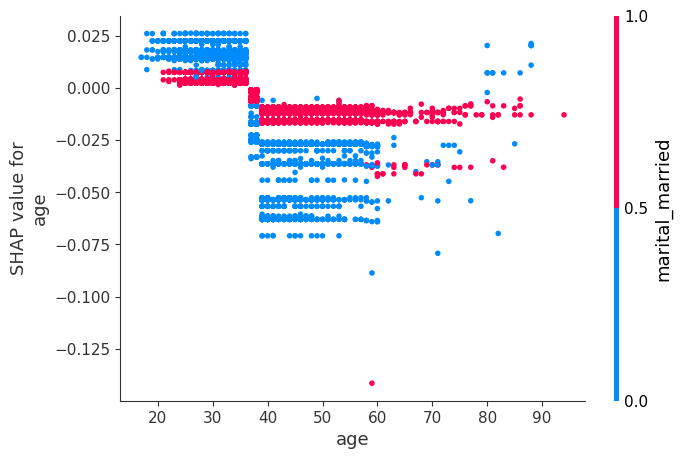

<Figure size 640x480 with 0 Axes>

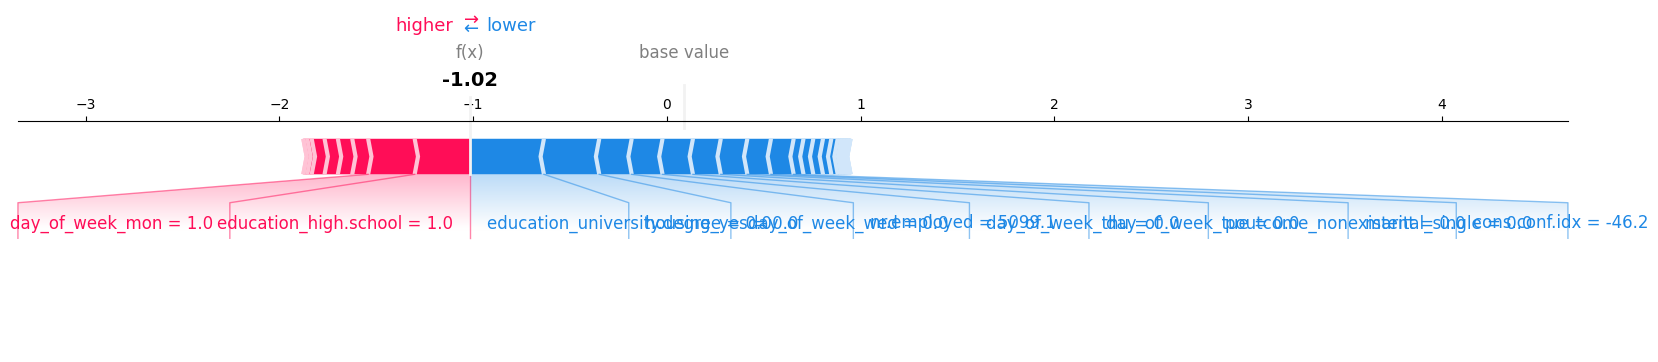

time: 4.1 s (started: 2026-04-19 03:52:53 +00:00)


In [33]:

#  SHAP EXPLAINABILITY

print("\n--- SHAP EXPLANATION ---")

import shap
import matplotlib.pyplot as plt
# Use TreeExplainer (since RandomForest is tree-based)
explainer = shap.TreeExplainer(best_model)

# Compute SHAP values
shap_values = explainer.shap_values(X_test)

# -------------------------------
# 1. GLOBAL FEATURE IMPORTANCE
# -------------------------------
plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=X_train_sm.columns, plot_type="bar")

# -------------------------------
# 2. DETAILED SUMMARY PLOT
# -------------------------------
plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=X_train_sm.columns)

# -------------------------------
# 3. DEPENDENCE PLOT
# -------------------------------
# Change feature name as needed
plt.figure()
shap.dependence_plot(
    X_train_sm.columns[0],  # example feature
    shap_values,
    X_test,
    feature_names=X_train_sm.columns # Provide feature names for clarity
)

# -------------------------------
# 4. LOCAL EXPLANATION (FORCE PLOT)
# -------------------------------
# Use expected value of class 1
expected_value = explainer.expected_value

plt.figure()
shap.force_plot(
    expected_value,
    shap_values[0], # shap_vals is now (num_samples, num_features), so shap_vals[0] is for the first sample
    X_test.iloc[0],
    matplotlib=True
)

In [34]:
from xgboost import XGBClassifier

name = "XGBoost"

# Model
model = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

# Parameters
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

best_model2 = hyper_parameter_tune(model, param_dist, X_train_sm, y_train_sm)



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:58:07] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best parameters: {'subsample': 1.0, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
Best CV accuracy: 0.8889
Test accuracy: 0.8792
time: 55.4 s (started: 2026-04-19 03:57:14 +00:00)



--- SHAP EXPLANATION ---


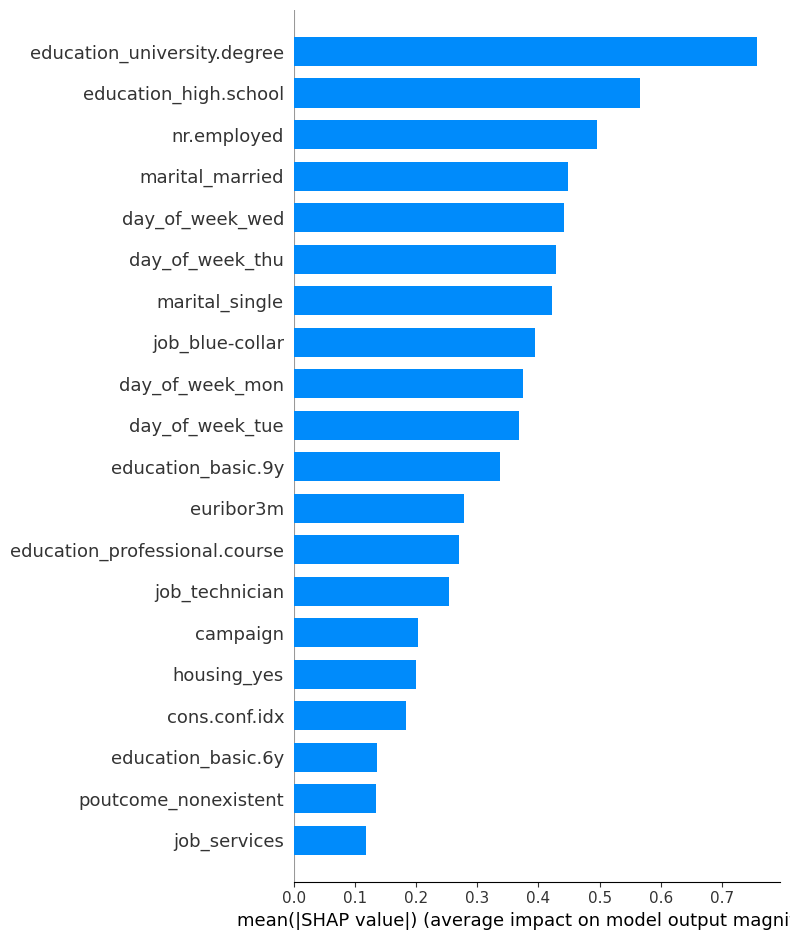

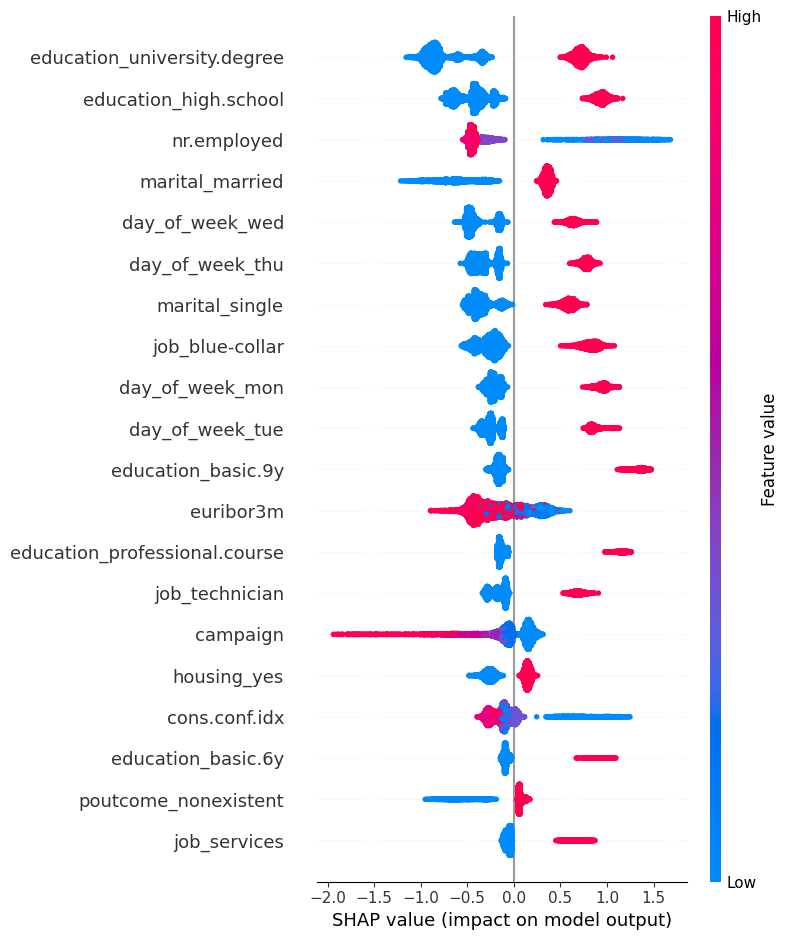

<Figure size 640x480 with 0 Axes>

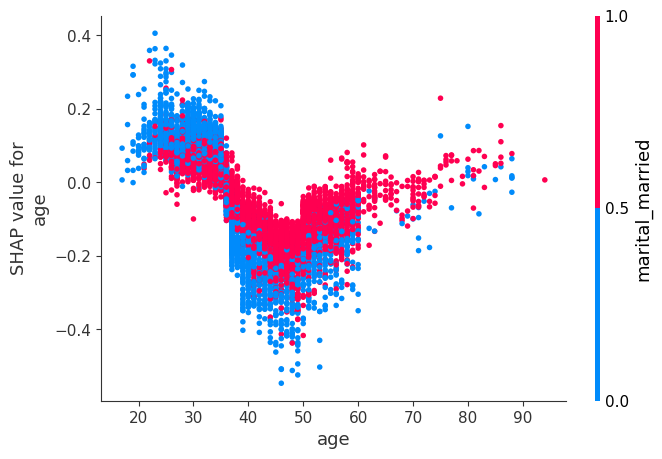

<Figure size 640x480 with 0 Axes>

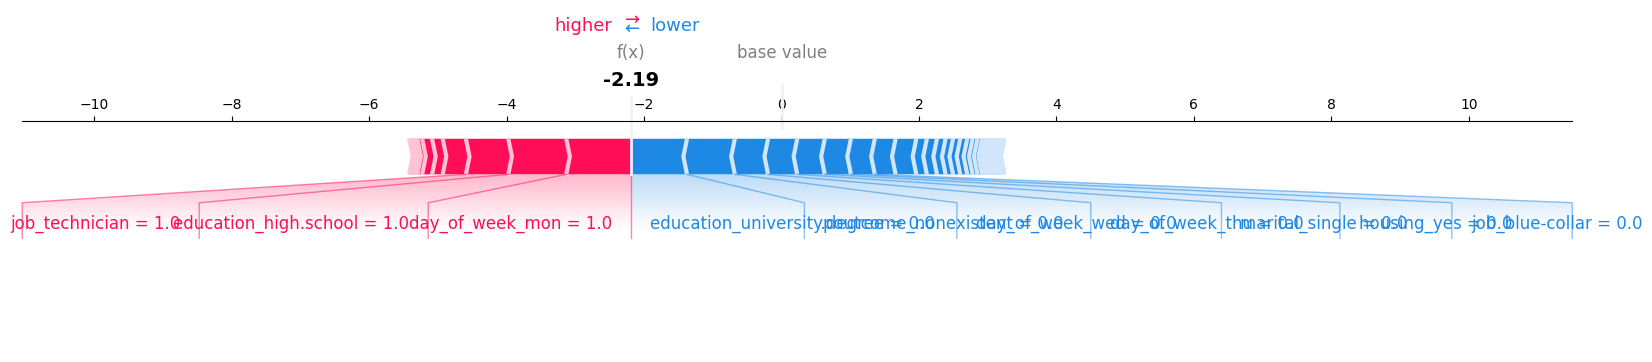

time: 20.8 s (started: 2026-04-19 03:58:09 +00:00)


In [35]:

#  SHAP EXPLAINABILITY

print("\n--- SHAP EXPLANATION ---")

import shap
import matplotlib.pyplot as plt
# Use TreeExplainer (since RandomForest is tree-based)
explainer = shap.TreeExplainer(best_model2)

# Compute SHAP values
shap_values = explainer.shap_values(X_test)

# -------------------------------
# 1. GLOBAL FEATURE IMPORTANCE
# -------------------------------
plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=X_train_sm.columns, plot_type="bar")

# -------------------------------
# 2. DETAILED SUMMARY PLOT
# -------------------------------
plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=X_train_sm.columns)

# -------------------------------
# 3. DEPENDENCE PLOT
# -------------------------------
# Change feature name as needed
plt.figure()
shap.dependence_plot(
    X_train_sm.columns[0],  # example feature
    shap_values,
    X_test,
    feature_names=X_train_sm.columns # Provide feature names for clarity
)

# -------------------------------
# 4. LOCAL EXPLANATION (FORCE PLOT)
# -------------------------------
# Use expected value of class 1
expected_value = explainer.expected_value

plt.figure()
shap.force_plot(
    expected_value,
    shap_values[0], # shap_vals is now (num_samples, num_features), so shap_vals[0] is for the first sample
    X_test.iloc[0],
    matplotlib=True
)

In [36]:
# LightGBM Import
from lightgbm import LGBMClassifier

name = "LightGBM"

# Model initialization
model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    reg_lambda=3,
    objective='binary',
    metric='accuracy',
    random_state=1,
    importance_type='gain',
    verbose=100
)

# Parameter distribution for tuning
param_dist = {
    'reg_lambda': [1, 3, 5, 7, 9],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

# Hyperparameter tuning call
best_model3 = hyper_parameter_tune(model, param_dist, X_train_sm, y_train_sm)

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[LightGBM] [Info] Number of positive: 29245, number of negative: 29245
[LightGBM] [Debug] Dataset::GetMultiBinFromSparseFeatures: sparse rate 0.859310
[LightGBM] [Debug] Dataset::GetMultiBinFromAllFeatures: sparse rate 0.680711
[LightGBM] [Debug] init for col-wise cost 0.020245 seconds, init for row-wise cost 0.026623 seconds
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.023934 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Debug] Using Sparse Multi-Val Bin
[LightGBM] [Info] Total Bins 1076
[LightGBM] [Info] Number of data points in the train set: 58490, number of used features: 45
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 6
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 6
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 6


--- SHAP EXPLANATION ---


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


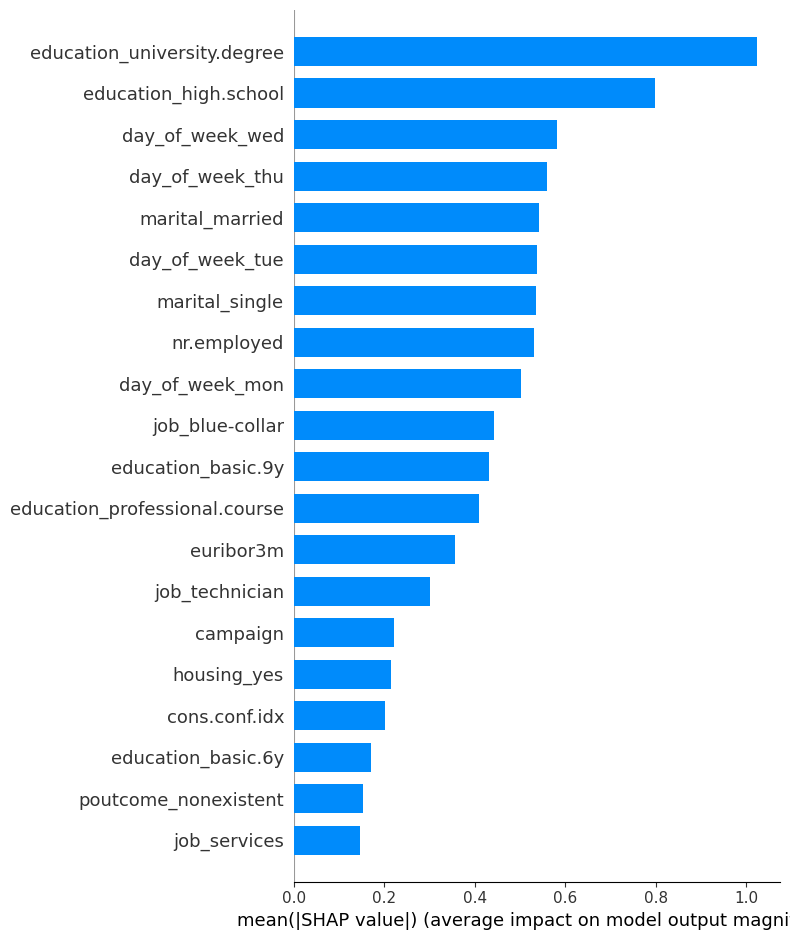

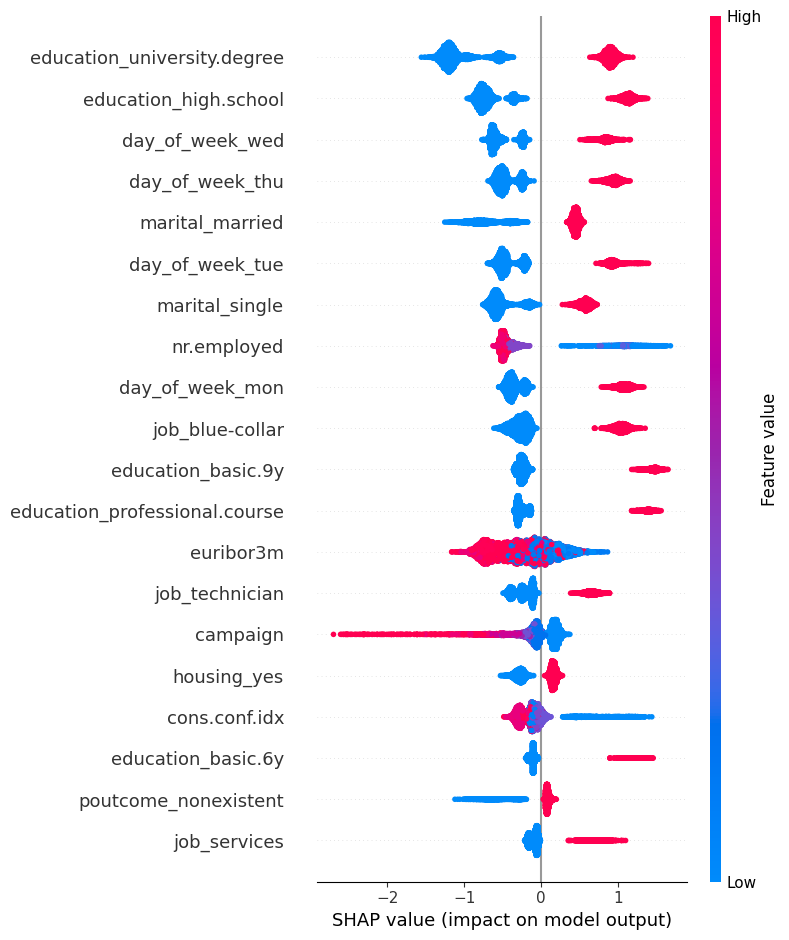

<Figure size 640x480 with 0 Axes>

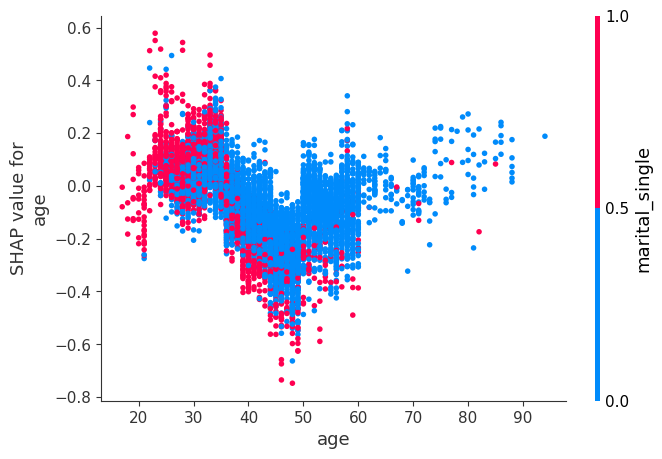

<Figure size 640x480 with 0 Axes>

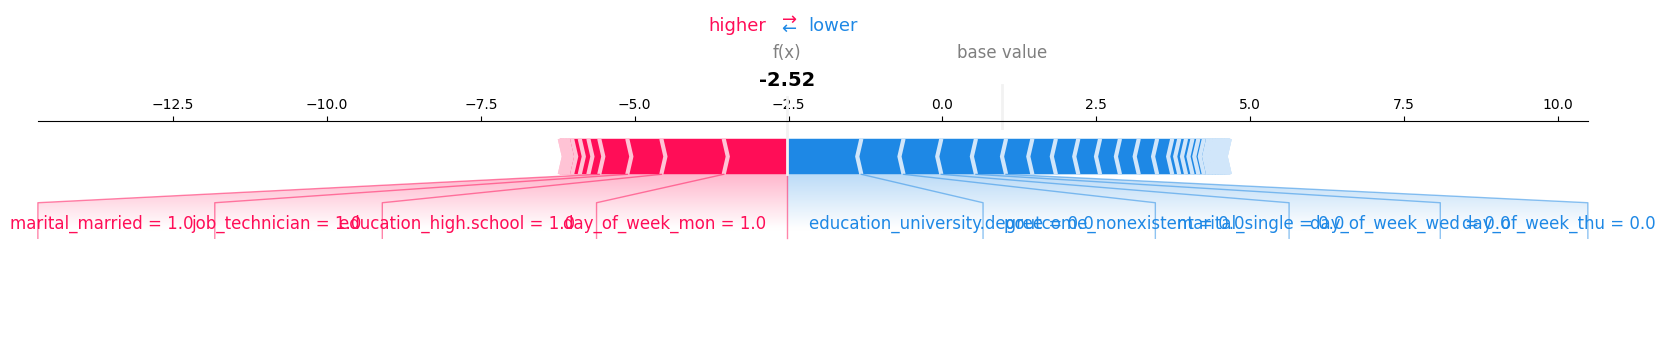

time: 26.8 s (started: 2026-04-19 03:59:13 +00:00)


In [37]:

#  SHAP EXPLAINABILITY

print("\n--- SHAP EXPLANATION ---")

import shap
import matplotlib.pyplot as plt
# Use TreeExplainer (since RandomForest is tree-based)
explainer = shap.TreeExplainer(best_model3)

# Compute SHAP values
shap_values = explainer.shap_values(X_test)

# -------------------------------
# 1. GLOBAL FEATURE IMPORTANCE
# -------------------------------
plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=X_train_sm.columns, plot_type="bar")

# -------------------------------
# 2. DETAILED SUMMARY PLOT
# -------------------------------
plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=X_train_sm.columns)

# -------------------------------
# 3. DEPENDENCE PLOT
# -------------------------------
# Change feature name as needed
plt.figure()
shap.dependence_plot(
    X_train_sm.columns[0],  # example feature
    shap_values,
    X_test,
    feature_names=X_train_sm.columns # Provide feature names for clarity
)

# -------------------------------
# 4. LOCAL EXPLANATION (FORCE PLOT)
# -------------------------------
# Use expected value of class 1
expected_value = explainer.expected_value

plt.figure()
shap.force_plot(
    expected_value,
    shap_values[0], # shap_vals is now (num_samples, num_features), so shap_vals[0] is for the first sample
    X_test.iloc[0],
    matplotlib=True
)

In [38]:
#*Catboost*
from catboost import CatBoostClassifier
name ="CatBoost"

# Model
model = CatBoostClassifier(
    iterations=200,
    learning_rate=0.1,
    depth=6,
    l2_leaf_reg=3,
    loss_function='Logloss',
    eval_metric='Accuracy',
    random_strength=1,
    bagging_temperature=1,
    verbose=100
)

param_dist = {
    'l2_leaf_reg': [1, 3, 5, 7, 9],
    'bagging_temperature': [0, 1, 5],
    'random_strength': [1, 2, 5]
}

best_model4 = hyper_parameter_tune(model, param_dist, X_train_sm, y_train_sm)

0:	learn: 0.7180373	total: 65.2ms	remaining: 13s
100:	learn: 0.8868354	total: 1.78s	remaining: 1.75s
199:	learn: 0.9111130	total: 3.47s	remaining: 0us
Best parameters: {'random_strength': 5, 'l2_leaf_reg': 3, 'bagging_temperature': 5}
Best CV accuracy: 0.8969
Test accuracy: 0.8806
time: 1min 43s (started: 2026-04-19 03:59:40 +00:00)



--- SHAP EXPLANATION ---


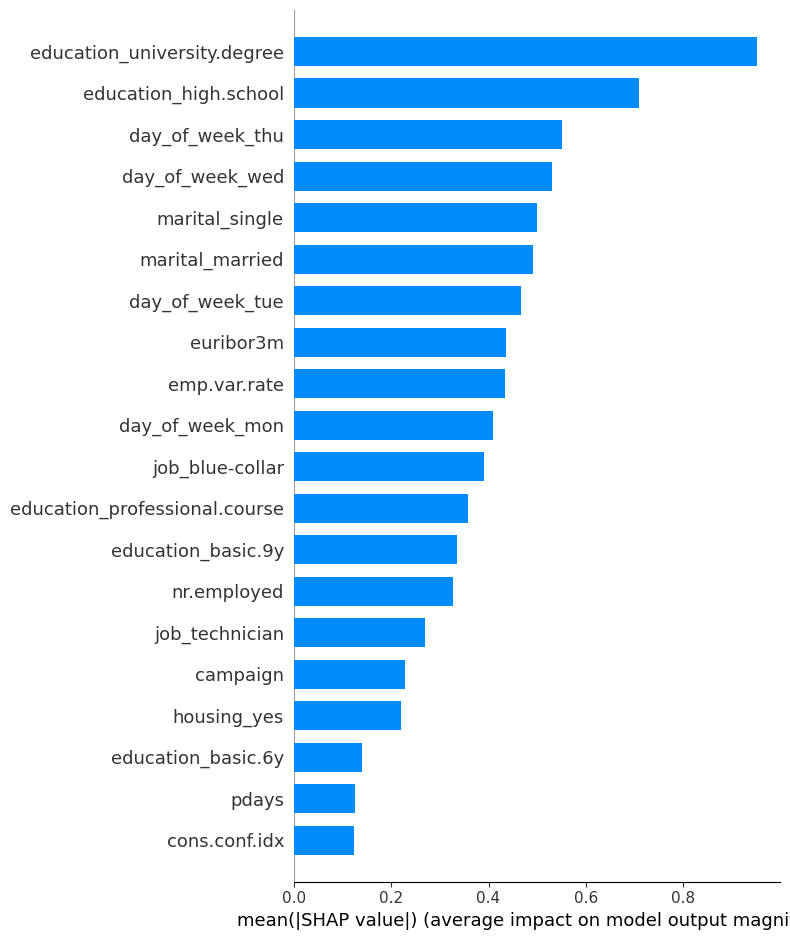

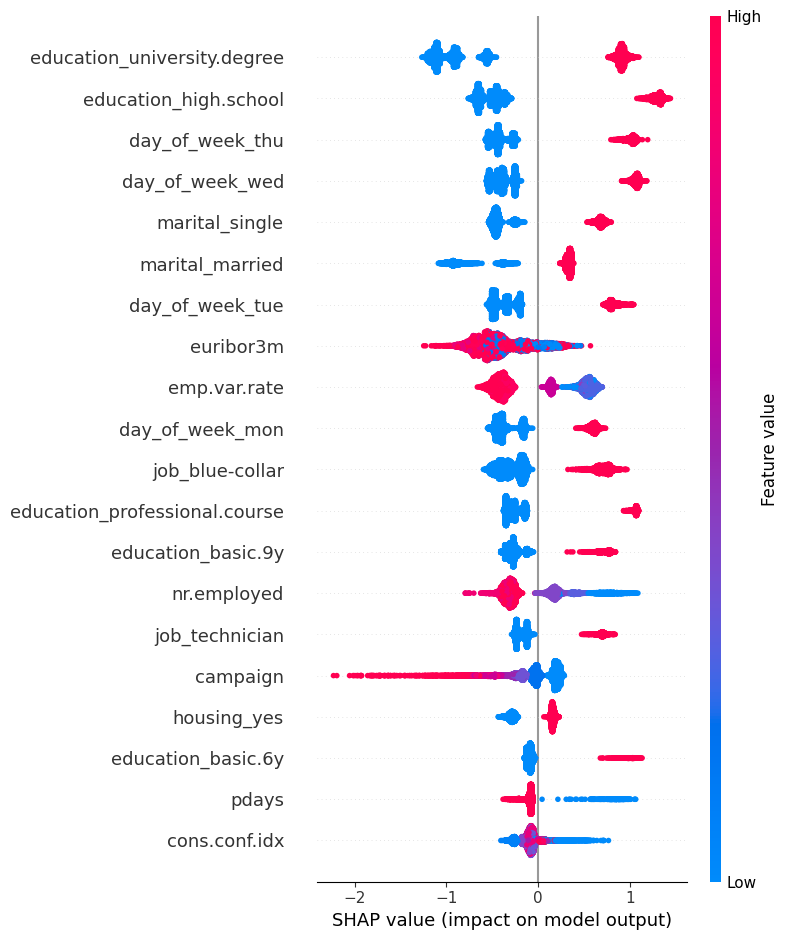

<Figure size 640x480 with 0 Axes>

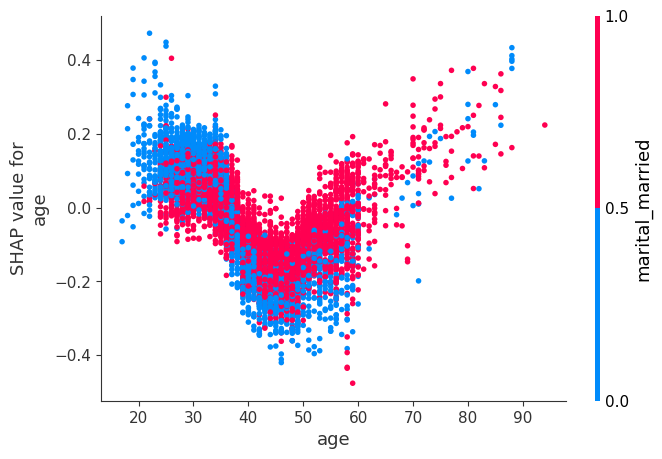

<Figure size 640x480 with 0 Axes>

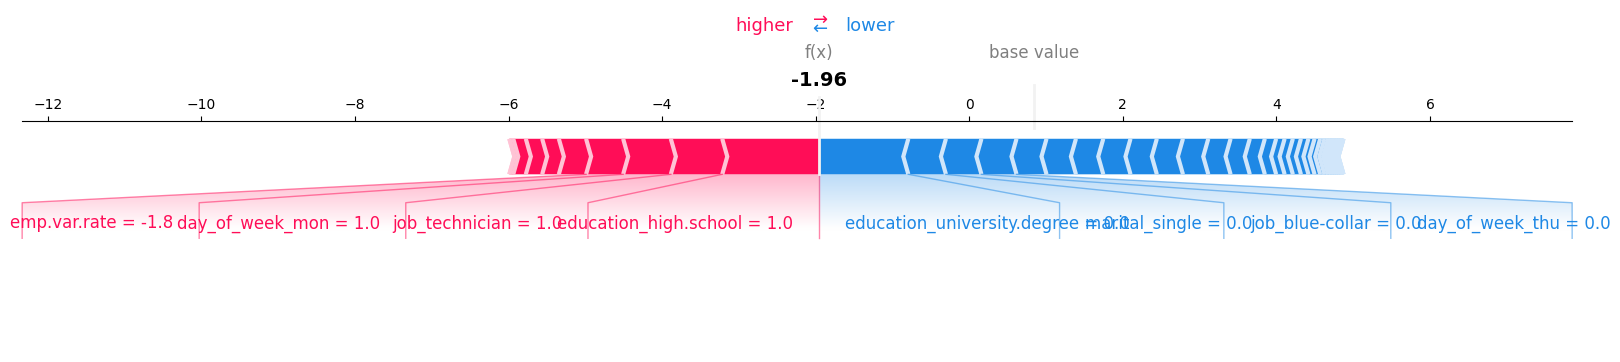

time: 4.51 s (started: 2026-04-19 04:01:24 +00:00)


In [39]:

#  SHAP EXPLAINABILITY

print("\n--- SHAP EXPLANATION ---")

import shap
import matplotlib.pyplot as plt
# Use TreeExplainer (since RandomForest is tree-based)
explainer = shap.TreeExplainer(best_model4)

# Compute SHAP values
shap_values = explainer.shap_values(X_test)

# -------------------------------
# 1. GLOBAL FEATURE IMPORTANCE
# -------------------------------
plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=X_train_sm.columns, plot_type="bar")

# -------------------------------
# 2. DETAILED SUMMARY PLOT
# -------------------------------
plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=X_train_sm.columns)

# -------------------------------
# 3. DEPENDENCE PLOT
# -------------------------------
# Change feature name as needed
plt.figure()
shap.dependence_plot(
    X_train_sm.columns[0],  # example feature
    shap_values,
    X_test,
    feature_names=X_train_sm.columns # Provide feature names for clarity
)

# -------------------------------
# 4. LOCAL EXPLANATION (FORCE PLOT)
# -------------------------------
# Use expected value of class 1
expected_value = explainer.expected_value

plt.figure()
shap.force_plot(
    expected_value,
    shap_values[0], # shap_vals is now (num_samples, num_features), so shap_vals[0] is for the first sample
    X_test.iloc[0],
    matplotlib=True
)